In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

<h2>Project Paths</h2>

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

<h2>Reload the Original Dataset</h2>

In [3]:
DATA_PATH = RAW_DATA_DIR / "online_retail_II.xlsx"

df_2009_2010 = pd.read_excel(
    DATA_PATH,
    sheet_name="Year 2009-2010"
)

df_2010_2011 = pd.read_excel(
    DATA_PATH,
    sheet_name="Year 2010-2011"
)

df = pd.concat(
    [df_2009_2010, df_2010_2011],
    ignore_index=True
)

df_raw = df.copy()

print(f"Initial rows: {len(df):,}")
print(f"Initial columns: {len(df.columns)}")

Initial rows: 1,067,371
Initial columns: 8


<h2>Cleaning Audit Log</h2>

In [4]:
cleaning_log = []

In [5]:
def log_cleaning_step(
    step,
    reason,
    rows_before,
    rows_after,
    action
):
    cleaning_log.append({
        "Step": step,
        "Reason": reason,
        "Rows Before": rows_before,
        "Rows After": rows_after,
        "Rows Affected": rows_before - rows_after,
        "Action": action
    })

<h2>Standardize Column Names</h2>

In [6]:
df = df.rename(columns={
    "Customer ID": "CustomerID",
    "Price": "UnitPrice"
})

In [7]:
df.columns.tolist()

['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

<h2>Standardize Data Types</h2>
<p>Invoice</p>

In [10]:
df["Invoice"] = (
    df["Invoice"]
    .astype("string")
    .str.strip()
)

<p>StockCode</p>

In [11]:
df["StockCode"] = (
    df["StockCode"]
    .astype("string")
    .str.strip()
)

<p>Description</p>

In [12]:
df["Description"] = (
    df["Description"]
    .astype("string")
)

<p>CustomerID</p>

In [13]:
df["CustomerID"] = pd.to_numeric(
    df["CustomerID"],
    errors="coerce"
)

<h2>Verify Date</h2>

In [14]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)

In [15]:
print(df["InvoiceDate"].dtype)

datetime64[us]


In [16]:
invalid_dates = df["InvoiceDate"].isna().sum()

print(f"Invalid dates: {invalid_dates:,}")

Invalid dates: 0


<h2>Investigate Duplicate Rows</h2>

In [17]:
duplicate_mask = df.duplicated(keep=False)

duplicate_rows = df[duplicate_mask].copy()

duplicate_rows["DuplicateValue"] = (
    duplicate_rows["Quantity"] *
    duplicate_rows["UnitPrice"]
)

duplicate_rows["DuplicateValue"].sum()

np.float64(857785.64)

In [18]:
duplicate_rows.head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,DuplicateValue
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,3.75
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,3.75
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,3.75
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,"16,329.00",United Kingdom,7.80
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,"16,329.00",United Kingdom,5.10
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,3.75
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,"16,329.00",United Kingdom,1.95
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,"16,329.00",United Kingdom,5.10
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,"16,329.00",United Kingdom,7.80
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,3.75


In [19]:
duplicate_rows[
    [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country"
    ]
].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,"16,329.00",United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,"16,329.00",United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,"16,329.00",United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,"16,329.00",United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,"16,329.00",United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom


<h2>Remove Exact Duplicates</h2>

In [20]:
rows_before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

rows_after = len(df)

log_cleaning_step(
    step="Exact duplicate removal",
    reason="Remove completely identical transaction records.",
    rows_before=rows_before,
    rows_after=rows_after,
    action="Dropped exact duplicate rows."
)

print(
    f"Removed {rows_before - rows_after:,} duplicate rows."
)

Removed 34,335 duplicate rows.


In [21]:
print(
    "Remaining duplicates:",
    df.duplicated().sum()
)

Remaining duplicates: 0


<h2>Investigate Missing Customer IDs</h2>

In [22]:
missing_customer = df["CustomerID"].isna()

missing_customer_value = (
    df.loc[missing_customer, "Quantity"] *
    df.loc[missing_customer, "UnitPrice"]
).sum()

print(
    f"Rows without CustomerID: "
    f"{missing_customer.sum():,}"
)

print(
    f"Transaction value associated with them: "
    f"£{missing_customer_value:,.2f}"
)

Rows without CustomerID: 235,151
Transaction value associated with them: £2,565,542.41


In [23]:
customer_status = (
    df["CustomerID"]
    .isna()
    .map({
        True: "Anonymous",
        False: "Identified"
    })
)

customer_status.value_counts()

CustomerID
Identified    797885
Anonymous     235151
Name: count, dtype: int64

<h2>Analyze Missing Customer IDs by Country</h2>

In [24]:
missing_customer_country = (
    df.assign(CustomerStatus=customer_status)
    .groupby(
        ["Country", "CustomerStatus"]
    )
    .size()
    .unstack(fill_value=0)
)

missing_customer_country["Anonymous %"] = (
    missing_customer_country["Anonymous"] /
    missing_customer_country.sum(axis=1) *
    100
)

missing_customer_country.sort_values(
    "Anonymous %",
    ascending=False
).head(20)

CustomerStatus,Anonymous,Identified,Anonymous %
Country,,,
Hong Kong,360,0,100.00
Bermuda,34,0,100.00
Bahrain,67,59,53.17
Unspecified,231,521,30.72
RSA,46,123,27.22
United Kingdom,232206,716115,24.49
United Arab Emirates,114,386,22.80
Lebanon,13,45,22.41
Israel,47,321,12.77


<h2>Analyze Missing Customer IDs Over Time</h2>

In [26]:
missing_customer_time = (
    df.loc[missing_customer]
    .set_index("InvoiceDate")
    .resample("ME")
    .size()
)

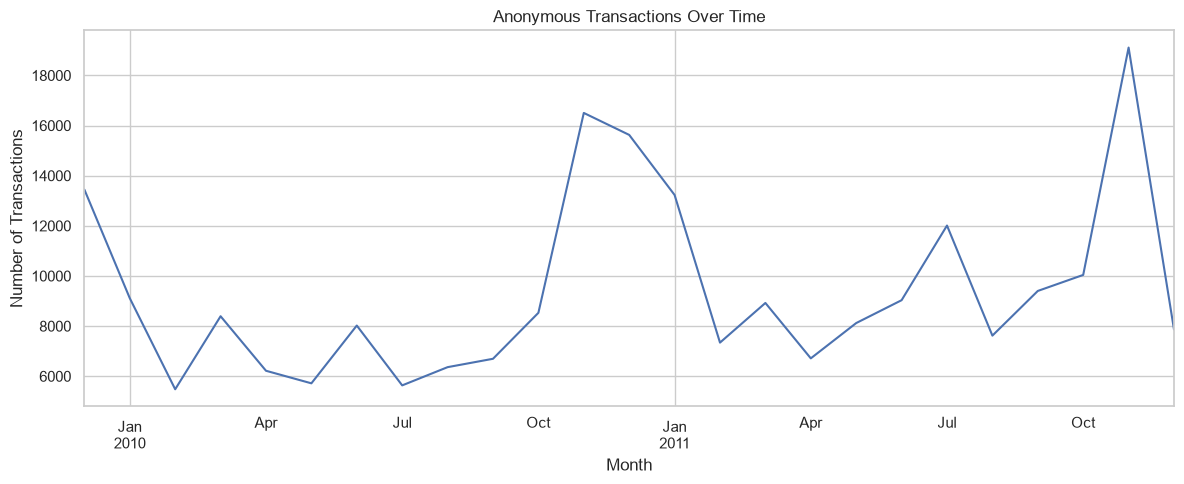

In [27]:
plt.figure(figsize=(12, 5))

missing_customer_time.plot()

plt.title("Anonymous Transactions Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

<h2>Decision: Keep Anonymous Transactions</h2>

<h2>Investigate Negative Quantity</h2>

In [28]:
returns = df[df["Quantity"] < 0].copy()

returns.head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,"16,321.00",Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,"16,321.00",Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,"16,321.00",Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,"16,321.00",Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,"16,321.00",Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,"16,321.00",Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,"17,592.00",United Kingdom


<h2>Calculate Return Value</h2>

In [29]:
returns["ReturnValue"] = (
    returns["Quantity"].abs() *
    returns["UnitPrice"]
)

print(
    f"Return rows: {len(returns):,}"
)

print(
    f"Returned item value: "
    f"£{returns['ReturnValue'].sum():,.2f}"
)

Return rows: 22,496
Returned item value: £1,462,424.18


<h2>Check Cancelled Invoices</h2>

In [30]:
returns["IsCancelledInvoice"] = (
    returns["Invoice"]
    .str.startswith("C")
)

In [31]:
returns["IsCancelledInvoice"].value_counts()

IsCancelledInvoice
True     19103
False     3393
Name: count, dtype: Int64

<h2>Create Sales and Returns Datasets</h2>

In [32]:
sales_df = df[df["Quantity"] > 0].copy()

returns_df = df[df["Quantity"] < 0].copy()

In [33]:
print(
    f"Sales rows: {len(sales_df):,}"
)

print(
    f"Return rows: {len(returns_df):,}"
)

Sales rows: 1,010,540
Return rows: 22,496


In [34]:
print(
    f"Combined: "
    f"{len(sales_df) + len(returns_df):,}"
)

Combined: 1,033,036


<h2>Add Transaction Type</h2>

In [35]:
df["TransactionType"] = np.where(
    df["Quantity"] < 0,
    "Return",
    "Sale"
)

In [36]:
df["TransactionType"].value_counts()

TransactionType
Sale      1010540
Return      22496
Name: count, dtype: int64

<h2>Investigate Zero Prices</h2>

In [37]:
zero_price_df = df[
    df["UnitPrice"] == 0
].copy()

zero_price_df.head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom,Return
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom,Return
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom,Return
462,489521,21646,<NA>,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom,Return
3077,489655,20683,<NA>,-44,2009-12-01 17:26:00,0.00,NaN,United Kingdom,Return
3124,489659,21350,<NA>,230,2009-12-01 17:39:00,0.00,NaN,United Kingdom,Sale
3125,489660,35956,lost,-1043,2009-12-01 17:43:00,0.00,NaN,United Kingdom,Return
3131,489663,35605A,damages,-117,2009-12-01 18:02:00,0.00,NaN,United Kingdom,Return
3687,489781,84292,<NA>,17,2009-12-02 11:45:00,0.00,NaN,United Kingdom,Sale
4233,489806,18010,<NA>,-770,2009-12-02 12:42:00,0.00,NaN,United Kingdom,Return


In [38]:
zero_price_df[
    "Description"
].value_counts().head(30)

Description
check                              160
?                                   90
damages                             83
damaged                             81
found                               28
missing                             27
sold as set on dotcom               20
Damaged                             17
adjustment                          16
OWL DOORSTOP                        14
POLYESTER FILLER PAD 45x45cm        12
dotcom                              12
POLYESTER FILLER PAD 40x40cm        10
smashed                              9
Found                                9
FRENCH BLUE METAL DOOR SIGN 1        9
thrown away                          9
Unsaleable, destroyed.               9
PICNIC BASKET WICKER LARGE           8
checked                              8
BOX OF 24 COCKTAIL PARASOLS          8
RED KITCHEN SCALES                   8
IVORY KITCHEN SCALES                 8
RECIPE BOX PANTRY YELLOW DESIGN      8
amazon                               8
FRENCH BLUE M

In [39]:
zero_price_df[
    "Country"
].value_counts().head(20)

Country
United Kingdom    5987
Germany              8
Netherlands          5
EIRE                 5
Australia            3
Belgium              1
Switzerland          1
Spain                1
RSA                  1
France               1
Norway               1
Name: count, dtype: int64

In [40]:
zero_price_df[
    "StockCode"
].value_counts().head(30)

StockCode
46000M    17
79321     17
22501     17
23084     16
21116     15
22423     15
46000S    14
84990     13
20713     13
22734     13
35965     13
22502     12
84016     11
22469     11
71477     10
22139     10
22470     10
22627     10
22087     10
22950     10
22197      9
22467      9
22719      9
21181      9
47566B     9
82583      9
22625      9
22689      9
22676      9
22084      9
Name: count, dtype: int64[pyarrow]

<h2>Decision on Zero Prices</h2>

In [41]:
df["IsZeroPrice"] = (
    df["UnitPrice"] == 0
)

<h2>Negative Prices</h2>

In [42]:
negative_price_df = df[
    df["UnitPrice"] < 0
]

negative_price_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType,IsZeroPrice
177338,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,"-53,594.36",NaN,United Kingdom,Sale,False
273025,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,"-44,031.79",NaN,United Kingdom,Sale,False
398731,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,"-38,925.87",NaN,United Kingdom,Sale,False
794040,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,"-11,062.06",NaN,United Kingdom,Sale,False
794041,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,"-11,062.06",NaN,United Kingdom,Sale,False


<h2>Remove Negative-Price Transactions from Analytical Sales Data</h2>

In [43]:
negative_price_mask = df["UnitPrice"] < 0

print(
    f"Negative price rows: "
    f"{negative_price_mask.sum():,}"
)

Negative price rows: 5


<h2>Clean Product Descriptions</h2>

In [44]:
print(
    f"Missing descriptions: "
    f"{df['Description'].isna().sum():,}"
)

Missing descriptions: 4,275


<h2>Strip Whitespace</h2>

In [45]:
df["Description"] = (
    df["Description"]
    .str.strip()
)

<h2>Standardize Case</h2>

In [46]:
df["DescriptionClean"] = (
    df["Description"]
    .str.upper()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

<h2>Compare Descriptions</h2>

In [47]:
description_comparison = (
    df[
        ["Description", "DescriptionClean"]
    ]
    .drop_duplicates()
)

description_comparison.head(30)

,Description,DescriptionClean
0,15CM CHRISTMAS GLASS BALL 20 LIGHTS,15CM CHRISTMAS GLASS BALL 20 LIGHTS
1,PINK CHERRY LIGHTS,PINK CHERRY LIGHTS
2,WHITE CHERRY LIGHTS,WHITE CHERRY LIGHTS
3,"RECORD FRAME 7"" SINGLE SIZE","RECORD FRAME 7"" SINGLE SIZE"
4,STRAWBERRY CERAMIC TRINKET BOX,STRAWBERRY CERAMIC TRINKET BOX
5,PINK DOUGHNUT TRINKET POT,PINK DOUGHNUT TRINKET POT
6,SAVE THE PLANET MUG,SAVE THE PLANET MUG
7,FANCY FONT HOME SWEET HOME DOORMAT,FANCY FONT HOME SWEET HOME DOORMAT
8,CAT BOWL,CAT BOWL
9,"DOG BOWL , CHASING BALL DESIGN","DOG BOWL , CHASING BALL DESIGN"


<h2>Count Unique Descriptions Before/After</h2>

In [48]:
original_description_count = (
    df["Description"]
    .nunique(dropna=True)
)

clean_description_count = (
    df["DescriptionClean"]
    .nunique(dropna=True)
)

print(
    f"Original unique descriptions: "
    f"{original_description_count:,}"
)

print(
    f"Clean unique descriptions: "
    f"{clean_description_count:,}"
)

Original unique descriptions: 5,655
Clean unique descriptions: 5,620


<h2>Datetime Features</h2>

In [49]:
df["Year"] = df["InvoiceDate"].dt.year

df["Month"] = df["InvoiceDate"].dt.month

df["MonthName"] = df["InvoiceDate"].dt.month_name()

df["Quarter"] = df["InvoiceDate"].dt.quarter

df["Day"] = df["InvoiceDate"].dt.day

df["DayOfWeek"] = df["InvoiceDate"].dt.dayofweek

df["DayName"] = df["InvoiceDate"].dt.day_name()

df["Hour"] = df["InvoiceDate"].dt.hour

df["IsWeekend"] = (
    df["DayOfWeek"] >= 5
)

<h2>Create Year-Month</h2>

In [50]:
df["YearMonth"] = (
    df["InvoiceDate"]
    .dt.to_period("M")
)

In [51]:
df[
    [
        "InvoiceDate",
        "Year",
        "Month",
        "MonthName",
        "Quarter",
        "DayOfWeek",
        "DayName",
        "Hour",
        "YearMonth"
    ]
].head()

,InvoiceDate,Year,Month,MonthName,Quarter,DayOfWeek,DayName,Hour,YearMonth
0,2009-12-01 07:45:00,2009,12,December,4,1,Tuesday,7,2009-12
1,2009-12-01 07:45:00,2009,12,December,4,1,Tuesday,7,2009-12
2,2009-12-01 07:45:00,2009,12,December,4,1,Tuesday,7,2009-12
3,2009-12-01 07:45:00,2009,12,December,4,1,Tuesday,7,2009-12
4,2009-12-01 07:45:00,2009,12,December,4,1,Tuesday,7,2009-12


<h2>Create Total Price</h2>

In [52]:
df["TotalPrice"] = (
    df["Quantity"] *
    df["UnitPrice"]
)

In [53]:
df[
    [
        "Quantity",
        "UnitPrice",
        "TotalPrice"
    ]
].head()

,Quantity,UnitPrice,TotalPrice
0,12,6.95,83.40
1,12,6.75,81.00
2,12,6.75,81.00
3,48,2.10,100.80
4,24,1.25,30.00


<h2>Validate TotalPrice</h2>

In [54]:
validation = (
    df["TotalPrice"] ==
    df["Quantity"] * df["UnitPrice"]
)

print(
    f"Correct calculations: "
    f"{validation.all()}"
)

Correct calculations: True


<h2>Detect UnitPrice Outliers — IQR</h2>

In [55]:
positive_price = df[
    df["UnitPrice"] > 0
]["UnitPrice"]

In [56]:
Q1 = positive_price.quantile(0.25)
Q3 = positive_price.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")

Q1: 1.25
Q3: 4.15
IQR: 2.90
Lower bound: -3.10
Upper bound: 8.50


<h2>Flag IQR Outliers</h2>

In [57]:
df["PriceOutlier_IQR"] = (
    (df["UnitPrice"] < lower_bound) |
    (df["UnitPrice"] > upper_bound)
)

In [58]:
print(
    f"IQR outliers: "
    f"{df['PriceOutlier_IQR'].sum():,}"
)

IQR outliers: 66,196


<h2>Z-Score Outliers</h2>

In [59]:
price_values = df["UnitPrice"].copy()

price_values_nonzero = price_values[
    price_values > 0
]

In [60]:
z_scores = pd.Series(
    np.nan,
    index=df.index
)

z_scores.loc[
    price_values_nonzero.index
] = np.abs(
    stats.zscore(
        price_values_nonzero
    )
)

In [61]:
df["PriceOutlier_ZScore"] = (
    z_scores > 3
)

In [62]:
print(
    f"Z-score outliers: "
    f"{df['PriceOutlier_ZScore'].sum():,}"
)

Z-score outliers: 810


<h2>Compare IQR vs Z-Score</h2>

In [63]:
outlier_comparison = pd.Series({
    "IQR Only": (
        df["PriceOutlier_IQR"] &
        ~df["PriceOutlier_ZScore"]
    ).sum(),

    "Z-Score Only": (
        df["PriceOutlier_ZScore"] &
        ~df["PriceOutlier_IQR"]
    ).sum(),

    "Both": (
        df["PriceOutlier_IQR"] &
        df["PriceOutlier_ZScore"]
    ).sum(),

    "Neither": (
        ~df["PriceOutlier_IQR"] &
        ~df["PriceOutlier_ZScore"]
    ).sum()
})

outlier_comparison

IQR Only         65386
Z-Score Only         0
Both               810
Neither         966840
dtype: int64

<h2>Inspect Extreme Price Records</h2>

In [64]:
df[
    df["PriceOutlier_IQR"]
][
    [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "CustomerID",
        "Country"
    ]
].sort_values(
    "UnitPrice",
    ascending=False
).head(30)

,Invoice,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
717220,C556445,M,Manual,-1,"38,970.00","15,098.00",United Kingdom
238929,512771,M,Manual,1,"25,111.09",NaN,United Kingdom
238926,C512770,M,Manual,-1,"25,111.09","17,399.00",United Kingdom
316822,C520667,BANK CHARGES,Bank Charges,-1,"18,910.69",NaN,United Kingdom
1015891,C580605,AMAZONFEE,AMAZON FEE,-1,"17,836.46",NaN,United Kingdom
539587,C540117,AMAZONFEE,AMAZON FEE,-1,"16,888.02",NaN,United Kingdom
539588,C540118,AMAZONFEE,AMAZON FEE,-1,"16,453.71",NaN,United Kingdom
512481,C537651,AMAZONFEE,AMAZON FEE,-1,"13,541.33",NaN,United Kingdom
511151,537632,AMAZONFEE,AMAZON FEE,1,"13,541.33",NaN,United Kingdom
511149,C537630,AMAZONFEE,AMAZON FEE,-1,"13,541.33",NaN,United Kingdom


<h2>Final Analytical Dataset</h2>

In [65]:
analytical_df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] >= 0)
].copy()

<h2>Verify</h2>

In [66]:
print(
    f"Original rows: "
    f"{len(df):,}"
)

print(
    f"Analytical sales rows: "
    f"{len(analytical_df):,}"
)

Original rows: 1,033,036
Analytical sales rows: 1,010,535


In [67]:
print(
    "Negative quantities:",
    (analytical_df["Quantity"] < 0).sum()
)

print(
    "Negative prices:",
    (analytical_df["UnitPrice"] < 0).sum()
)

Negative quantities: 0
Negative prices: 0


<h2>Create Returns Dataset</h2>

In [68]:
returns_df = df[
    df["Quantity"] < 0
].copy()

In [69]:
returns_df["ReturnValue"] = (
    returns_df["Quantity"].abs() *
    returns_df["UnitPrice"]
)

<h2>Create Net Sales Value</h2>

In [70]:
gross_sales = analytical_df["TotalPrice"].sum()

In [71]:
total_returns = returns_df["ReturnValue"].sum()

In [72]:
net_sales = gross_sales - total_returns

In [73]:
print(f"Gross sales: £{gross_sales:,.2f}")
print(f"Returns:     £{total_returns:,.2f}")
print(f"Net sales:   £{net_sales:,.2f}")

Gross sales: £20,476,634.02
Returns:     £1,462,424.18
Net sales:   £19,014,209.84


<h2>Return Rate</h2>

In [74]:
return_transaction_rate = (
    len(returns_df) /
    len(df) *
    100
)

return_value_rate = (
    total_returns /
    gross_sales *
    100
)

print(
    f"Return transaction rate: "
    f"{return_transaction_rate:.2f}%"
)

print(
    f"Return value rate: "
    f"{return_value_rate:.2f}%"
)

Return transaction rate: 2.18%
Return value rate: 7.14%


<h2>Complete Cleaning Audit</h2>

In [75]:
cleaning_log_df = pd.DataFrame(
    cleaning_log
)

cleaning_log_df

,Step,Reason,Rows Before,Rows After,Rows Affected,Action
0,Exact duplicate removal,Remove completely identical transaction records.,1067371,1033036,34335,Dropped exact duplicate rows.


In [76]:
cleaning_log_df.to_csv(
    REPORTS_DIR / "cleaning_audit_log.csv",
    index=False
)

<h2>Save Processed Data</h2>

In [77]:
analytical_path = (
    PROCESSED_DATA_DIR /
    "online_retail_cleaned.csv"
)

analytical_df.to_csv(
    analytical_path,
    index=False
)

In [78]:
returns_path = (
    PROCESSED_DATA_DIR /
    "online_retail_returns.csv"
)

returns_df.to_csv(
    returns_path,
    index=False
)

In [79]:
print("Saved:")
print(analytical_path)
print(returns_path)

Saved:
/Users/karthikeyanj/Desktop/projects/E-Commerce-Life-Cycle-Analysis/data/processed/online_retail_cleaned.csv
/Users/karthikeyanj/Desktop/projects/E-Commerce-Life-Cycle-Analysis/data/processed/online_retail_returns.csv


<h2>Final Validation</h2>

In [80]:
print("========== FINAL VALIDATION ==========")

print(
    f"Rows: {len(analytical_df):,}"
)

print(
    f"Columns: {len(analytical_df.columns)}"
)

print(
    f"Missing CustomerID: "
    f"{analytical_df['CustomerID'].isna().sum():,}"
)

print(
    f"Negative Quantity: "
    f"{(analytical_df['Quantity'] < 0).sum():,}"
)

print(
    f"Negative UnitPrice: "
    f"{(analytical_df['UnitPrice'] < 0).sum():,}"
)

print(
    f"Zero UnitPrice: "
    f"{(analytical_df['UnitPrice'] == 0).sum():,}"
)

print(
    f"Duplicate rows: "
    f"{analytical_df.duplicated().sum():,}"
)

print(
    f"Gross Sales: £{gross_sales:,.2f}"
)

print(
    f"Returns: £{total_returns:,.2f}"
)

print(
    f"Net Sales: £{net_sales:,.2f}"
)

========== FINAL VALIDATION ==========
Rows: 1,010,535
Columns: 24
Missing CustomerID: 231,040
Negative Quantity: 0
Negative UnitPrice: 0
Zero UnitPrice: 2,621
Duplicate rows: 0
Gross Sales: £20,476,634.02
Returns: £1,462,424.18
Net Sales: £19,014,209.84


<paragraph>
RAW EXCEL 
    ->
Load both years
    ->
Combine
    ->
Standardize column names
    ->
Standardize data types
    ->
Remove exact duplicates
    ->
Investigate missing CustomerID
    ->
Flag returns
    ->
Separate sales / returns
    ->
Investigate zero prices
    ->
Flag negative prices
    ->
Clean descriptions
    ->
Extract datetime features
    ->
Create TotalPrice
    ->
IQR outlier detection
    ->
Z-score outlier detection
    ->
Compare outlier methods
    ->
Create analytical sales dataset
    ->
Create returns dataset
    ->
Calculate gross / returns / net sales
    ->
VALIDATED DATA
</paragraph>